# Telco Customer Churn Analysis

Business Analytics Case Study

## Business Problem
Customer churn is a major chllenge in the telecommunications industry because loosing existing customers directly affects revenue and increases the cost of acquiring new ones. This project aims to identify the key factors influencing customer churn and provide data driven recommendations to help the company improve customer retention and make informed buisness decisions.

## Project Objectives

The objective of this analysis are to:

- Assess the overall customer churn rate.
- Understand the charactersistics of the customer base.
- Identify the key factors that influence customer churn.
- Analyze customer behaviour across different demographicand servuce related attributes.
- Discover trends and patterns associated with customer retention.
- Generates actionable market insigts to support decision-making.
- Recommended practical strategies to reduce customer loyalty.

## Dataset Description
The dataset contains customer information from a telecommunications company, including demographic details, account information, and customer churn status. Each row represents a unique customer, while the columns describe various characteristics that may influence whether a customer stays with or leaves the company. The target variable is Churn, which indicates whethr a customer discontinued the service.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')

## Load Dataset

In [2]:
telco =pd.read_csv('Telco_Customer_Churn.csv', encoding="Latin1")


## Dataset Understanding

In [3]:
# Display the first 10 Rows
telco.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
# Display the last 10 rows
telco.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [5]:
telco.shape

(7043, 21)

In [6]:
telco.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
telco.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [8]:
telco.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
(telco['TotalCharges'] == ''). sum()

np.int64(0)

In [10]:
telco.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [11]:
telco.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
telco['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
round(telco['Churn'].value_counts(normalize=True) * 100 , 2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

## Data Cleaning

Data cleaning is an essential step in the analytics process. It ensures the dataset is accurate, consistent, and suitable for analysis by addressing the missing values, incorrect data types, and other quality issues.

In [14]:
# Check for blank vales in TotalCharges
(telco['TotalCharges'] == ''). sum()

np.int64(0)

In [15]:

# Convert TotalCharges to Numeric 
telco['TotalCharges']=pd.to_numeric(telco['TotalCharges'],errors='coerce')

# Fill missing values with median
telco['TotalCharges']=telco['TotalCharges'].fillna(telco['TotalCharges'].median())

In [16]:
# Verify Data Types
telco.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [17]:
# Display the cleaned Dateset
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning Summary

The following preprocessing steps were completed:

- Checked for missing values.
- Converted the 'TotalCharges' column to a numeric datatype
- Replaced missing values with the median.
- Confirmed the dataset was clean and ready for exploratoty data analysis.

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand customer behaviour, Identify trends and patterns, and uncover the key factprs influencing customer churn. The insights obtained from this analysis will guide the buisness recommendations provided at the end of the study. 

## Analysis 1: Customer Churn Distribution

C:\Users\USER\AppData\Local\Temp\ipykernel_19472\1566747956.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=telco, x='Churn', palette='Blues')


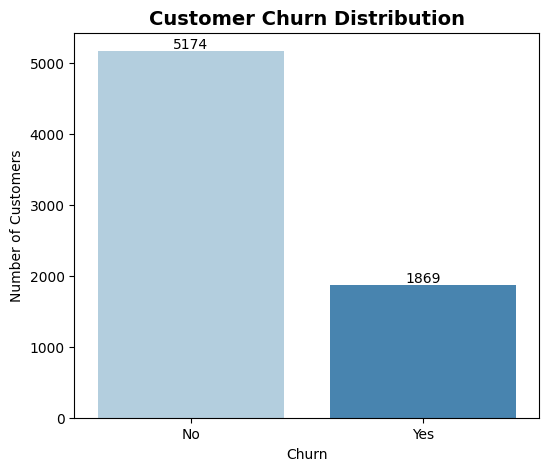

In [18]:
# Customer Churn Distribution

plt.figure(figsize=(6,5))

ax = sns.countplot(data=telco, x='Churn', palette='Blues')

plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

# Display values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()


## Observation
The majority of customers remained with the company, while a smaller proportion discontinued the service . This indicates that although customer retention is relatively strong , a significant number of customers still churned, presenting an opportunity for the company to improve retention startegies.

## Business Insights
Customer churn represents a direct loss of revenue and increases the cost of acquiring new customers. understanding the charactersitics of customers who leave the company will enable management to design targeted retention strategies and improve long-term profitability.


## Analysis 2: Churn Percentage

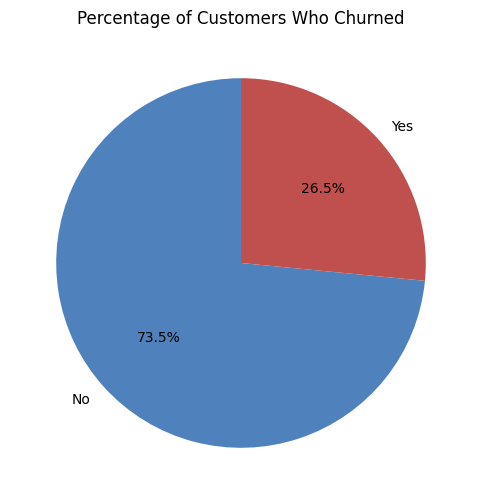

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [19]:
# Churn Percentage

churn_rate = telco['Churn'].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))

plt.pie(
    churn_rate,
    labels=churn_rate.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4F81BD', '#C0504D']
)

plt.title('Percentage of Customers Who Churned')

plt.show()

print(churn_rate)

## Observation
Approximately one-quater of the customers have churned, while the majority have remained with the company. Although, the retention rate is higher than the churn rate, the percentage of customers leaving the company is substaintially enough to warrant further investigation.

## Buisness Insights
Reducing customer churn by even a small percentage can have a significant impact on company revenue and customer lifetime value. Identifying the factors contributing to churn should therefoere be a strategic business priority.

## Analysis 3: Contract Type vs Customer Churn

This analysis examines whether the type of customer contract influences the likelihood of customer churn.

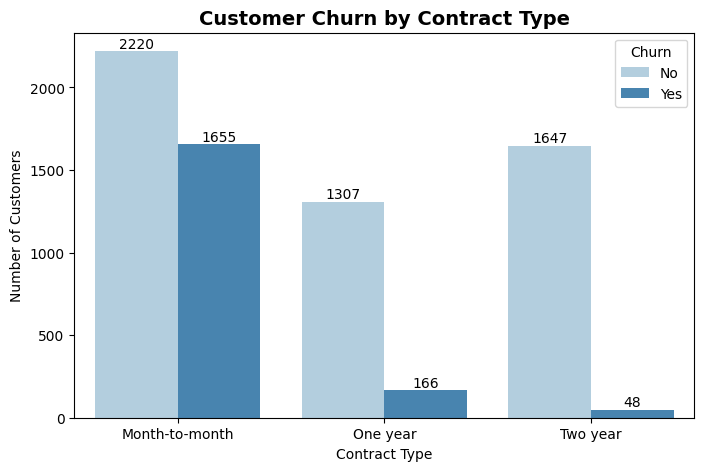

In [20]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=telco,
    x='Contract',
    hue='Churn',
    palette='Blues'
)

plt.title('Customer Churn by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers on month-to-month contracts recorded the highest number of churn cases. In contrast, customers with one-year and two-year contracts showed significantly lower churn rates.

### Business Insight

Contract type is a major factor influencing customer retention. Customers with long-term contracts are more likely to remain with the company, while month-to-month customers are at a much higher risk of leaving. Encouraging customers to switch to longer-term contracts could significantly reduce churn.

## Analysis 4: Internet Service vs Customer Churn

This analysis investigates whether the type of internet service subscribed to affects customer churn.

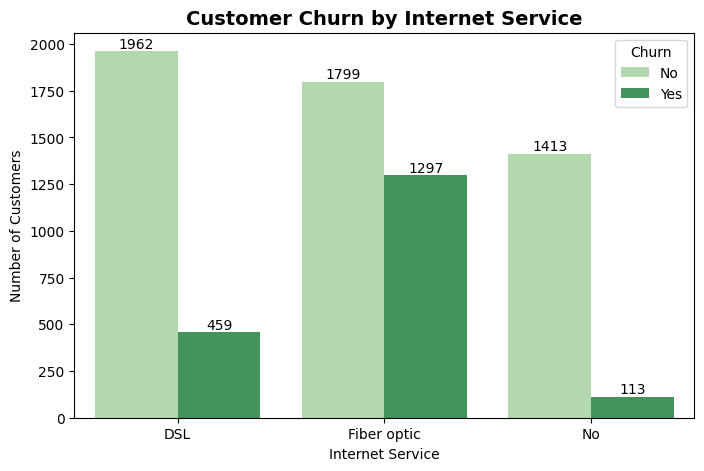

In [21]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=telco,
    x='InternetService',
    hue='Churn',
    palette='Greens'
)

plt.title('Customer Churn by Internet Service', fontsize=14, fontweight='bold')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

# Add values on bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers using Fiber Optic internet services appear to have a higher number of churn cases compared to customers using DSL services or those without internet service.

### Business Insight

The company should further investigate the Fiber Optic customer segment to determine whether pricing, service quality, or customer expectations are contributing to the higher churn rate. Addressing these issues could improve customer satisfaction and retention.

## Analysis 5: Monthly Charges vs Customer Churn

This analysis examines whether customers with higher monthly charges are more likely to churn than those with lower monthly charges.

C:\Users\USER\AppData\Local\Temp\ipykernel_19472\3671047918.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


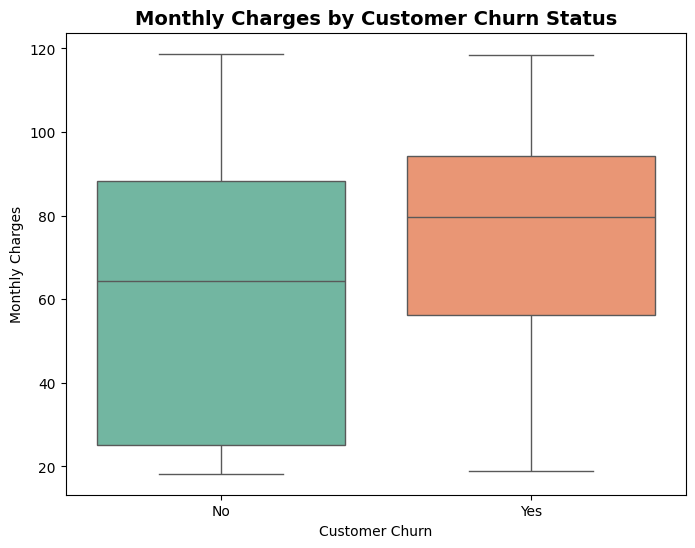

In [22]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=telco,
    x='Churn',
    y='MonthlyCharges',
    palette='Set2'
)

plt.title('Monthly Charges by Customer Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Customer Churn')
plt.ylabel('Monthly Charges')

plt.show()

### Observation

Customers who churned generally have higher monthly charges than customers who remained with the company. This suggests that pricing may influence customers' decisions to discontinue the service.

### Business Insight

Customers paying higher monthly charges may perceive the service as less valuable or too expensive. The company should evaluate its pricing strategy and consider offering personalized discounts or value-added services to high-paying customers who are at risk of churning.

## Analysis 6: Customer Tenure vs Customer Churn

This analysis investigates whether the length of time a customer has stayed with the company affects the likelihood of customer churn.

C:\Users\USER\AppData\Local\Temp\ipykernel_19472\146999380.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


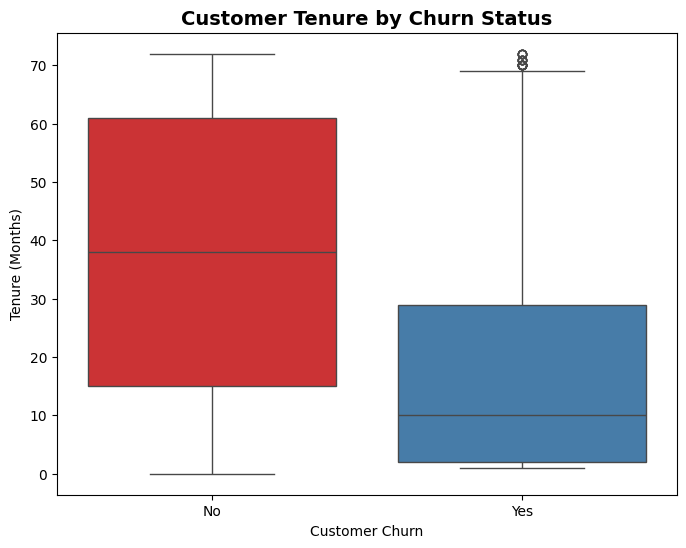

In [23]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=telco,
    x='Churn',
    y='tenure',
    palette='Set1'
)

plt.title('Customer Tenure by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Customer Churn')
plt.ylabel('Tenure (Months)')

plt.show()

### Observation

Customers who churned generally have much shorter tenures than customers who remained with the company. Long-term customers appear to be more loyal and less likely to leave.

### Business Insight

The first few months of a customer's relationship with the company are critical. Strengthening customer engagement, improving onboarding, and offering retention incentives during this period could significantly reduce churn.

## Analysis 7: Payment Method vs Customer Churn

This analysis explores whether customers' preferred payment methods are associated with different churn rates.

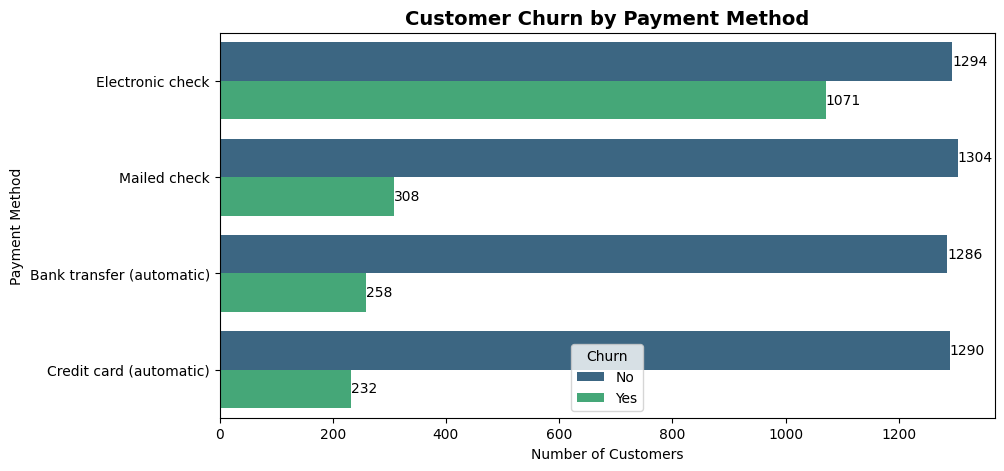

In [24]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=telco,
    y='PaymentMethod',
    hue='Churn',
    palette='viridis'
)

plt.title('Customer Churn by Payment Method', fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Payment Method')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers using Electronic Check appear to have a higher number of churn cases compared to customers using other payment methods.

### Business Insight

The company should investigate why customers paying by Electronic Check are more likely to leave. Encouraging automatic payment methods or improving the payment experience may help increase customer retention.

## Analysis 8: Online Security vs Customer Churn

This analysis examines whether subscribing to the Online Security service influences customer churn.

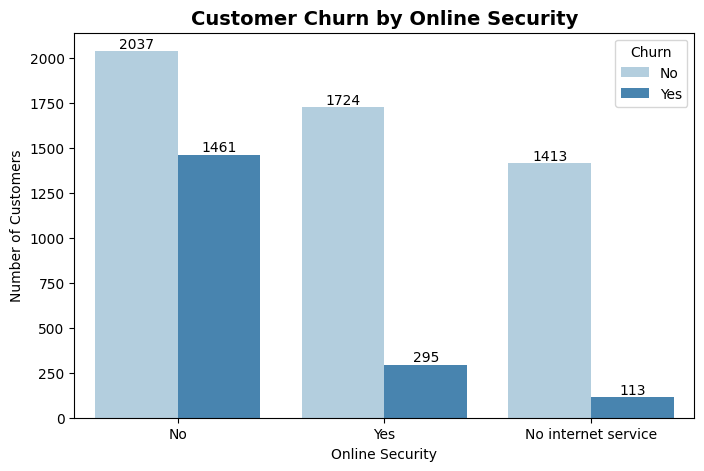

In [25]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=telco,
    x='OnlineSecurity',
    hue='Churn',
    palette='Blues'
)

plt.title('Customer Churn by Online Security', fontsize=14, fontweight='bold')
plt.xlabel('Online Security')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers without Online Security recorded a noticeably higher number of churn cases than customers who subscribed to the service.

### Business Insight

Online Security appears to improve customer retention. Promoting this service or bundling it with selected plans may encourage customers to stay longer.

## Analysis 9: Tech Support vs Customer Churn

This analysis investigates whether access to technical support affects customer churn.

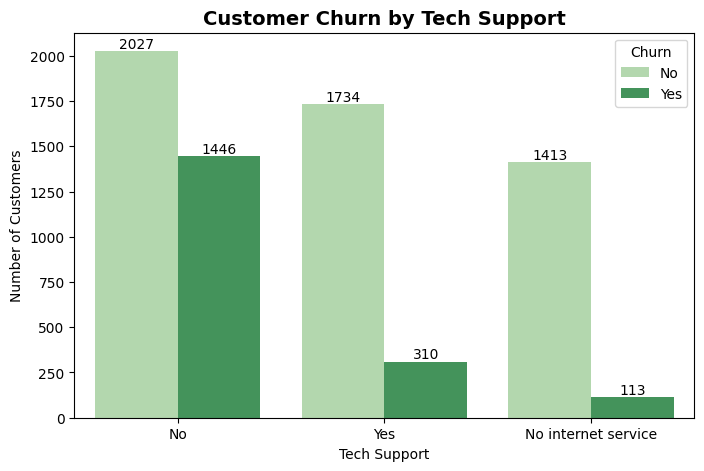

In [26]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=telco,
    x='TechSupport',
    hue='Churn',
    palette='Greens'
)

plt.title('Customer Churn by Tech Support', fontsize=14, fontweight='bold')
plt.xlabel('Tech Support')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers without Tech Support were more likely to churn than those who had access to technical support.

### Business Insight

Reliable customer support strengthens customer loyalty. Expanding access to Tech Support or offering it as part of premium plans could help reduce churn.

## Analysis 10: Online Backup vs Customer Churn

This analysis explores whether customers who subscribe to Online Backup services are less likely to churn.

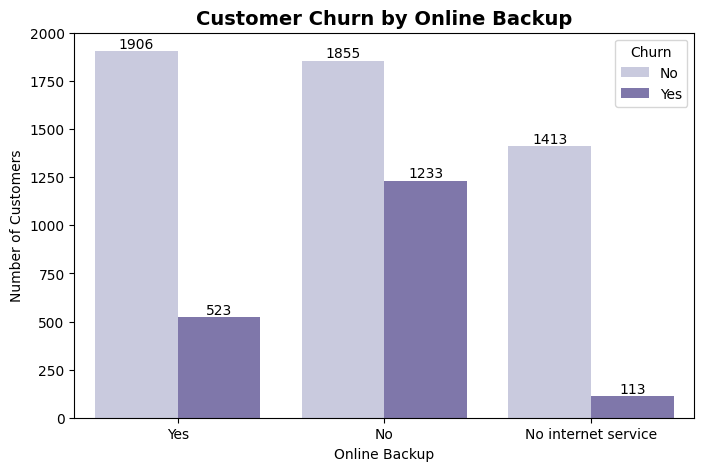

In [27]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=telco,
    x='OnlineBackup',
    hue='Churn',
    palette='Purples'
)

plt.title('Customer Churn by Online Backup', fontsize=14, fontweight='bold')
plt.xlabel('Online Backup')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers without Online Backup services showed a higher number of churn cases compared to customers who subscribed to the service.

### Business Insight

Offering Online Backup as part of bundled service packages may improve customer satisfaction and increase retention rates.

## Analysis 11: Device Protection vs Customer Churn

This analysis evaluates whether Device Protection services influence customer retention.

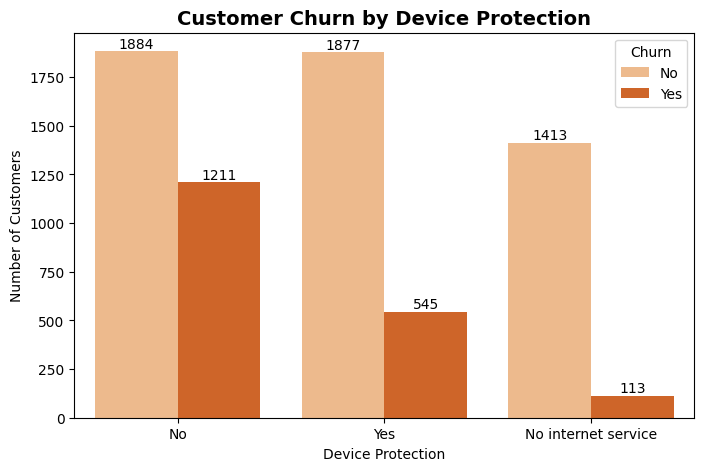

In [28]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=telco,
    x='DeviceProtection',
    hue='Churn',
    palette='Oranges'
)

plt.title('Customer Churn by Device Protection', fontsize=14, fontweight='bold')
plt.xlabel('Device Protection')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers who did not subscribe to Device Protection experienced higher churn than customers who had the service.

### Business Insight

Device Protection appears to contribute to customer retention. Bundling this service with other offerings may increase customer loyalty and reduce churn.

## Analysis 12: Gender vs Customer Churn

This analysis examines whether customer gender has any significant influence on churn.

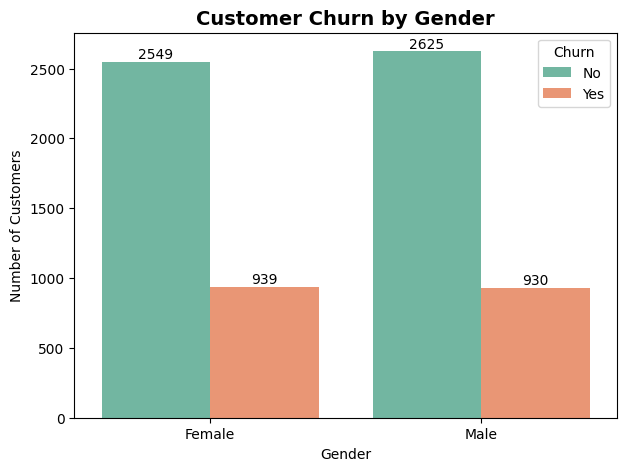

In [29]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=telco,
    x='gender',
    hue='Churn',
    palette='Set2'
)

plt.title('Customer Churn by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

The churn distribution is relatively similar for both male and female customers, indicating that gender alone does not appear to have a strong influence on customer churn.

### Business Insight

Customer retention strategies should not be based solely on gender. Other factors such as contract type, tenure, and service subscriptions are likely to have a greater impact on churn.

## Analysis 13: Senior Citizen vs Customer Churn

This analysis investigates whether senior citizens are more likely to churn than non-senior customers.

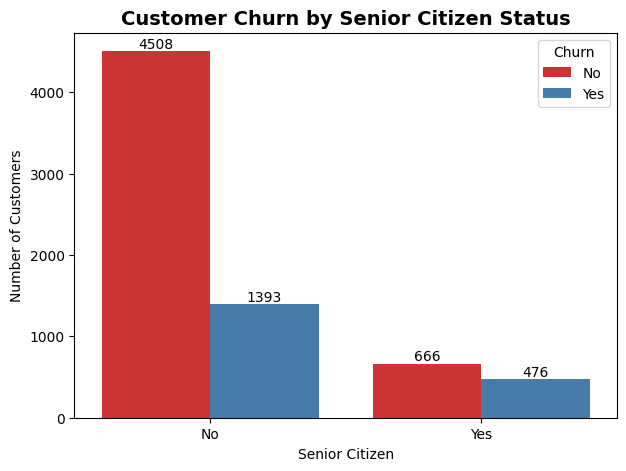

In [30]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=telco,
    x='SeniorCitizen',
    hue='Churn',
    palette='Set1'
)

plt.title('Customer Churn by Senior Citizen Status', fontsize=14, fontweight='bold')
plt.xlabel('Senior Citizen')
plt.ylabel('Number of Customers')
plt.xticks([0,1], ['No','Yes'])
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Senior citizens appear to have a higher proportion of churn compared to non-senior customers, although they represent a smaller share of the overall customer base.

### Business Insight

Senior citizens may benefit from tailored customer support, simplified service plans, or loyalty incentives designed to improve retention.

## Analysis 14: Partner vs Customer Churn

This analysis explores whether customers with partners exhibit different churn behavior compared to those without partners.

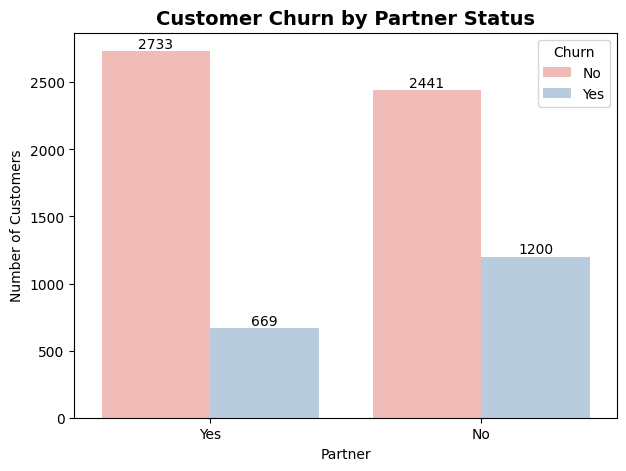

In [31]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=telco,
    x='Partner',
    hue='Churn',
    palette='Pastel1'
)

plt.title('Customer Churn by Partner Status', fontsize=14, fontweight='bold')
plt.xlabel('Partner')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers without partners recorded a higher number of churn cases than customers with partners.

### Business Insight

Customers with partners may have stronger long-term service commitments. Personalized retention campaigns could be developed for customers without partners, who appear to be more likely to leave.

## Analysis 15: Dependents vs Customer Churn

This analysis examines whether having dependents influences customer churn.

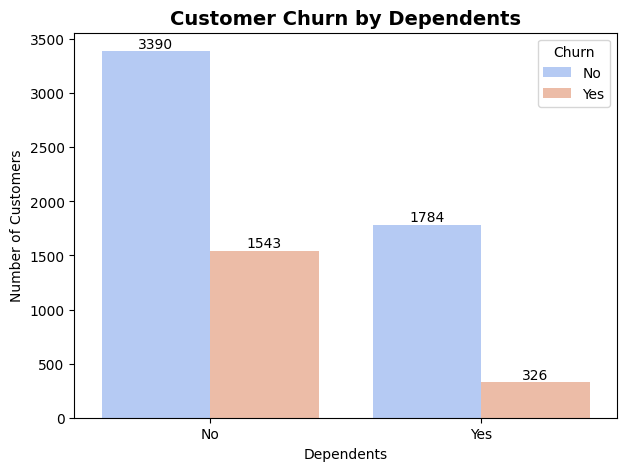

In [32]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=telco,
    x='Dependents',
    hue='Churn',
    palette='coolwarm'
)

plt.title('Customer Churn by Dependents', fontsize=14, fontweight='bold')
plt.xlabel('Dependents')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers without dependents recorded more churn cases than customers with dependents, suggesting that family-related commitments may contribute to customer retention.

### Business Insight

Customers without dependents may require additional engagement through personalized offers, flexible plans, or loyalty rewards to reduce churn.

## Analysis 16: Paperless Billing vs Customer Churn

This analysis examines whether customers enrolled in paperless billing are more likely to churn.

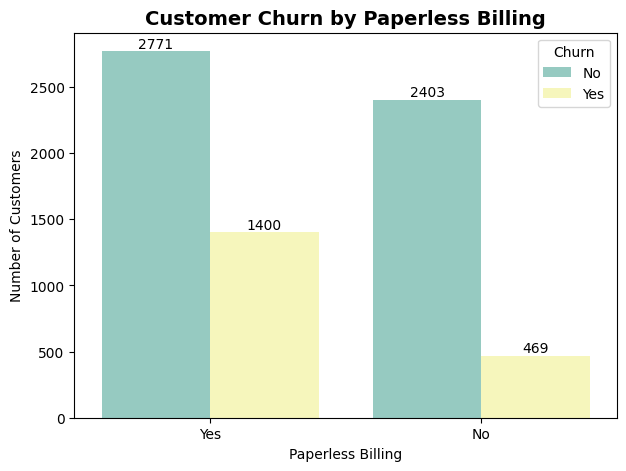

In [33]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=telco,
    x='PaperlessBilling',
    hue='Churn',
    palette='Set3'
)

plt.title('Customer Churn by Paperless Billing', fontsize=14, fontweight='bold')
plt.xlabel('Paperless Billing')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers using paperless billing appear to have a higher number of churn cases than those receiving paper bills.

### Business Insight

The company should further investigate whether paperless billing customers have other characteristics, such as month-to-month contracts or higher monthly charges, that contribute to churn.

## Analysis 17: Streaming TV vs Customer Churn

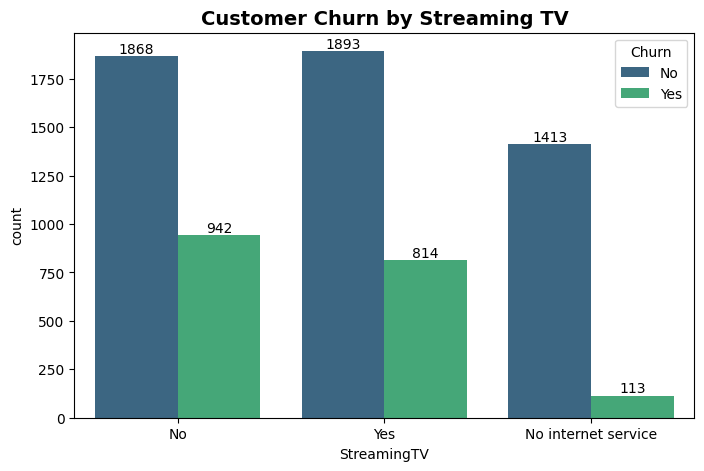

In [34]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=telco,
    x='StreamingTV',
    hue='Churn',
    palette='viridis'
)

plt.title('Customer Churn by Streaming TV', fontsize=14, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers without Streaming TV services recorded more churn cases than customers who subscribed to the service.

### Business Insight

Bundling entertainment services with internet packages may improve customer satisfaction and encourage long-term retention.

## Analysis 18: Streaming Movies vs Customer Churn

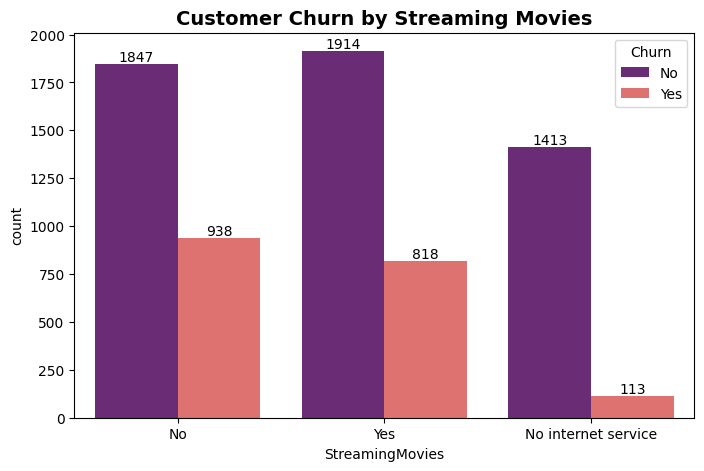

In [35]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=telco,
    x='StreamingMovies',
    hue='Churn',
    palette='magma'
)

plt.title('Customer Churn by Streaming Movies', fontsize=14, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers without Streaming Movies services showed a higher tendency to churn compared to customers who subscribed to the service.

### Business Insight

Entertainment-related services may increase customer engagement. Bundled offers could strengthen customer loyalty and reduce churn.

## Analysis 19: Phone Service vs Customer Churn

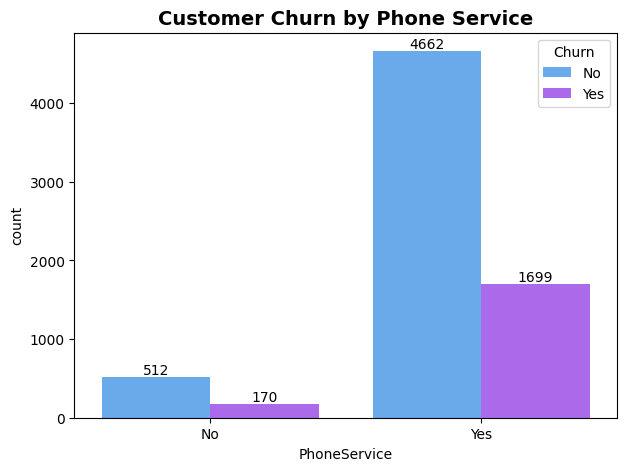

In [36]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=telco,
    x='PhoneService',
    hue='Churn',
    palette='cool'
)

plt.title('Customer Churn by Phone Service', fontsize=14, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Most customers have phone service, and churn occurs in both groups. Phone service alone does not appear to be a major driver of customer churn.

### Business Insight

Rather than focusing solely on phone service, the company should consider combinations of services and customer characteristics when designing retention strategies.

## Analysis 20: Multiple Lines vs Customer Churn

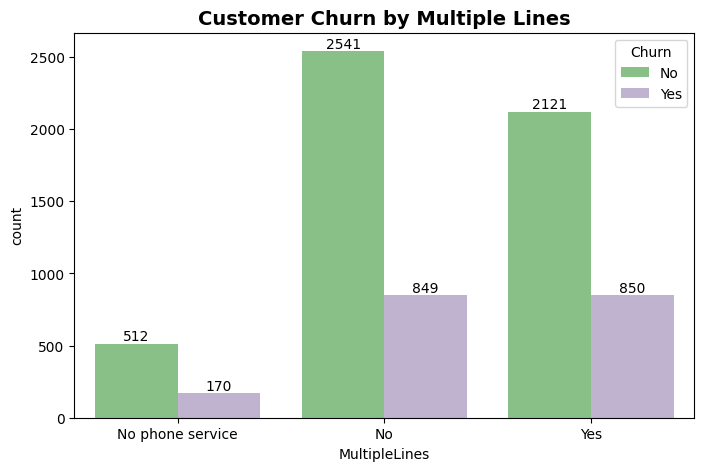

In [37]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=telco,
    x='MultipleLines',
    hue='Churn',
    palette='Accent'
)

plt.title('Customer Churn by Multiple Lines', fontsize=14, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Observation

Customers with and without multiple phone lines experienced churn. The differences are less pronounced than for factors such as contract type or tenure.

### Business Insight

Multiple phone lines alone are not a strong predictor of churn. Other variables should be prioritized when identifying high-risk customers.

## Analysis 21: Correlation Heatmap

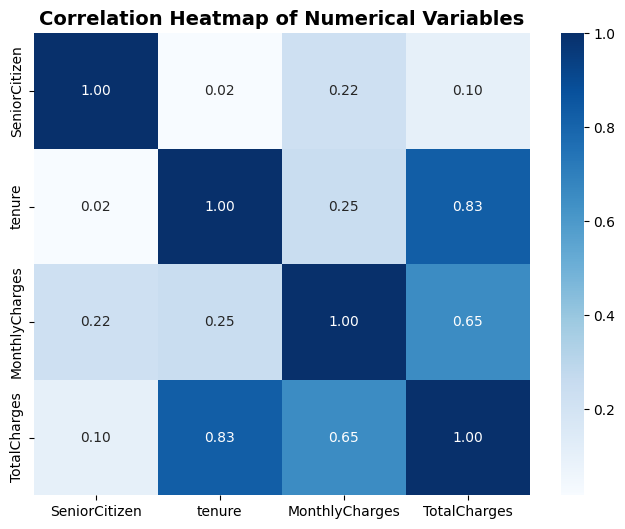

In [38]:
plt.figure(figsize=(8,6))

numeric_data = telco.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_data.corr(),
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numerical Variables', fontsize=14, fontweight='bold')

plt.show()

### Observation

The heatmap shows the relationships between numerical variables. While some variables exhibit moderate correlations, no extremely strong correlations are observed, suggesting that multiple factors collectively influence customer churn.

### Business Insight

Customer churn is driven by a combination of demographic, service, and billing factors rather than a single variable. This highlights the importance of considering multiple customer attributes when developing retention strategies.

# Key Findings

The analysis revealed the following key findings:

1. Customers on **month-to-month contracts** exhibited the highest churn rates compared to those on one-year and two-year contracts.

2. Customers with **shorter tenure** were significantly more likely to churn than long-term customers.

3. Customers paying **higher monthly charges** showed a greater tendency to leave the company.

4. Customers using **Fiber Optic internet service** experienced higher churn than customers using DSL or those without internet service.

5. Customers without **Online Security**, **Tech Support**, **Online Backup**, and **Device Protection** services were more likely to churn.

6. **Electronic Check** was the payment method most commonly associated with customer churn.

7. **Senior citizens** showed a higher proportion of churn than non-senior customers.

8. Gender had little influence on customer churn compared to contract type, tenure, and subscribed services.

9. Customers without partners or dependents generally experienced higher churn rates.

10. Customer churn is influenced by multiple business and customer-related factors rather than a single variable.

# Business Insights

The analysis highlights several important business insights:

- Long-term customer relationships significantly improve customer retention.

- Customers who subscribe to additional value-added services are generally more loyal and less likely to churn.

- Pricing plays an important role in customer retention, particularly for customers with higher monthly charges.

- The early stages of the customer lifecycle present the greatest risk of churn, emphasizing the importance of effective onboarding and engagement.

- Customer retention strategies should focus on high-risk customer segments identified through contract type, tenure, billing, and subscribed services rather than relying solely on demographic characteristics.

# Recommendations

Based on the findings from this analysis, the following recommendations are proposed:

### 1. Encourage Long-Term Contracts

Offer attractive discounts and incentives to encourage customers on month-to-month contracts to switch to one-year or two-year plans.

### 2. Strengthen Customer Onboarding

Develop onboarding programs and engagement campaigns targeting customers during their first twelve months of service.

### 3. Review Pricing Strategy

Evaluate pricing for customers with high monthly charges and consider introducing personalized discounts or bundled service packages.

### 4. Promote Value-Added Services

Increase adoption of Online Security, Tech Support, Device Protection, and Online Backup by offering promotional bundles and free trial periods.

### 5. Improve Customer Retention Campaigns

Use customer segmentation to proactively identify high-risk customers and provide personalized retention offers before they decide to leave.

# Conclusion

This business analytics case study identified several key factors influencing customer churn within the telecommunications industry. Contract type, tenure, monthly charges, internet service, and value-added services emerged as the strongest predictors of customer churn.

The findings demonstrate that customer retention requires a proactive and data-driven approach. By implementing targeted retention strategies, improving customer engagement, and encouraging the adoption of long-term contracts and additional services, the company can reduce churn, improve customer satisfaction, and increase long-term profitability.

Overall, this project demonstrates how business analytics can transform raw customer data into meaningful insights that support strategic decision-making and business growth.

# References

- IBM Sample Telco Customer Churn Dataset
- Kaggle: Telco Customer Churn Dataset
- AnalystLab Africa Data Analytics Internship Program (Week 5)